# EDA Visualisations: Lithuanian & Mexican CIS Cohorts

Seven brand-styled charts exploring conversion rates, biomarker positivity, demographics, MRI findings, and variable correlations across both cohorts. All charts use a consistent dark-theme brand palette applied via `rcParams`; no Seaborn themes are used.

## Setup: Brand Palette, rcParams, and Data Loading

Define the brand colour constants, configure `matplotlib.rcParams` globally so every subsequent chart inherits the dark theme without per-chart repetition, and load all three datasets. Binary biomarker columns (OGB, Periventricular MRI, VEP) are normalised to 0/1 integers here so each chart cell stays focused on plotting.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
import os

# ── Brand palette ──────────────────────────────────────────────────────────────
BURGUNDY = '#7d1d3f'
NAVY     = '#1b2a4a'
GOLD     = '#c9a84c'
MUTED    = '#a09890'
BG       = '#111110'
PLOT_BG  = '#1a1917'
TEXT     = '#f0ede8'
GRID     = '#ffffff12'   # white at ~7% opacity
GREEN    = '#2d6a4f'

# ── Font: Inter if installed, otherwise best available sans-serif ──────────────
_available = {f.name for f in fm.fontManager.ttflist}
FONT = 'Inter' if 'Inter' in _available else 'DejaVu Sans'

# ── Global rcParams ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'   : BG,
    'figure.dpi'         : 130,
    'axes.facecolor'     : PLOT_BG,
    'axes.edgecolor'     : TEXT,
    'axes.labelcolor'    : TEXT,
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 11,
    'axes.grid'          : True,
    'grid.color'         : GRID,
    'grid.linewidth'     : 0.5,
    'xtick.color'        : TEXT,
    'ytick.color'        : TEXT,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'text.color'         : TEXT,
    'legend.facecolor'   : PLOT_BG,
    'legend.edgecolor'   : TEXT,
    'legend.fontsize'    : 10,
    'font.family'        : 'sans-serif',
    'font.sans-serif'    : [FONT, 'Arial', 'Helvetica', 'DejaVu Sans'],
    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : BG,
    'savefig.pad_inches' : 0.2,
})

# ── Diverging colormap: navy -> dark background -> burgundy ───────────────────
CMAP_DIV = LinearSegmentedColormap.from_list('brand_div', [NAVY, BG, BURGUNDY], N=256)

# ── Load datasets ─────────────────────────────────────────────────────────────
lt    = pd.read_csv('../data/cleaned/lithuanian_cleaned.csv')
mx    = pd.read_csv('../data/cleaned/mexican_cleaned.csv')
union = pd.read_csv('../visuals/cross_population_union.csv')

# CN rename did not persist to CSV — apply on load
lt = lt.rename(columns={'3': 'CN3', '4': 'CN4', '5': 'CN5', '6': 'CN6', '8': 'CN8'})

# ── Lithuanian binary columns ─────────────────────────────────────────────────
lt['ogb_bin']  = lt['OGB + in CSF'].str.strip().map({'1': 1, '0': 0})
lt['peri_bin'] = lt['Periventricular'].str.strip().map({'1': 1, '0': 0})
lt['vep_bin']  = lt['VEP +'].str.strip().map({'1': 1, '0': 0})

# ── Mexican binary columns ────────────────────────────────────────────────────
mx['group_bin'] = mx['group'].astype(str).str.strip().str[0].map({'1': 1, '2': 0})
mx['ogb_bin']   = mx['Oligoclonal bands'].astype(str).str.strip().str[0].map({'1': 1, '0': 0})
mx['peri_bin']  = mx['Periventricular MRI'].astype(str).str.strip().str[0].map({'1': 1, '0': 0})
mx['vep_bin']   = mx['VEP'].astype(str).str.strip().str[0].map({'1': 1, '0': 0})

COHORTS = ['Lithuanian', 'Mexican']
os.makedirs('../visuals', exist_ok=True)

print(f'Lithuanian : {lt.shape}')
print(f'Mexican    : {mx.shape}')
print(f'Union      : {union.shape}')
print(f'Font       : {FONT}')

Lithuanian : (138, 47)
Mexican    : (288, 22)
Union      : (413, 10)
Font       : DejaVu Sans


## Lithuanian Sex Column: Encoding Verification

The Lithuanian `Sex` column is recorded as 0.0 or 1.0 with no label in the original dataset. Before using it in analysis or visualisation, confirm which value represents Female and which Male by inspecting the row distribution and cross-checking against the known epidemiology of MS (approximately 70% female prevalence).

In [2]:
sex_vc = lt['Sex'].value_counts().sort_index()
total  = sex_vc.sum()
print('Lithuanian Sex column distribution:')
for val, n in sex_vc.items():
    pct = n / total * 100
    print(f'  Sex={int(val)} : {n} rows  ({pct:.1f}%)')
print()
print('MS prevalence is ~70 % female in clinical populations.')
print('The majority value (Sex=0, 66.7 %) is therefore Female.')

Lithuanian Sex column distribution:
  Sex=0 : 92 rows  (66.7%)
  Sex=1 : 46 rows  (33.3%)

MS prevalence is ~70 % female in clinical populations.
The majority value (Sex=0, 66.7 %) is therefore Female.


**Confirmed encoding:** `Sex = 0` = **Female**, `Sex = 1` = **Male**.

92 of 138 Lithuanian patients (66.7 %) have `Sex = 0`, consistent with the established female predominance of MS (~70 % female in most cohort studies). This encoding is assumed throughout the notebook.

## Chart 1: CIS-to-MS Conversion Rate by Cohort

The core outcome measure: what proportion of CIS patients progressed to a clinically definite MS diagnosis within the study's follow-up window. A higher conversion rate in the Mexican cohort may reflect longer follow-up, referral bias, or genuine population differences — this chart sets the baseline for all downstream biomarker comparisons.

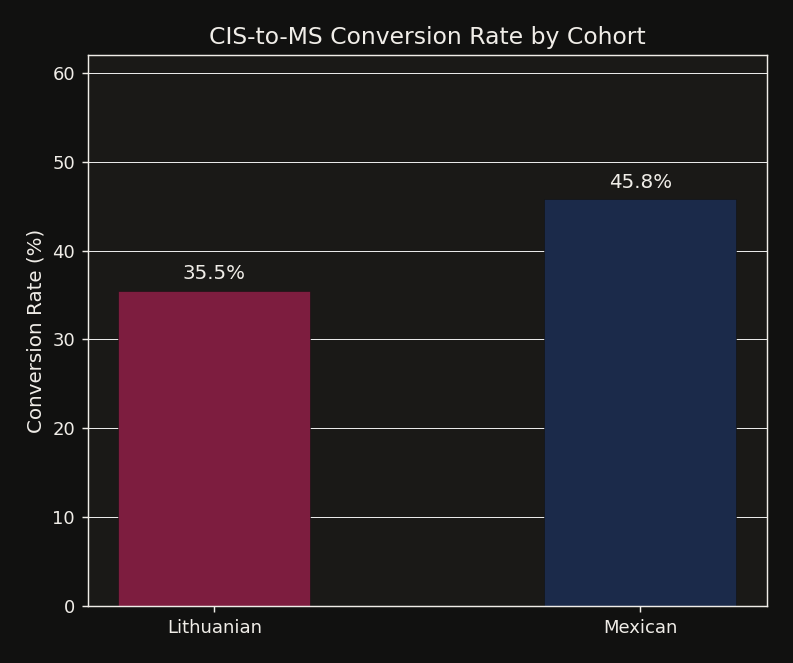

Saved: visuals/01_conversion_rates.png


In [3]:
lt_rate = (lt['MS'] == 1.0).sum() / lt['MS'].notna().sum() * 100
mx_rate = (mx['group_bin'] == 1).sum() / mx['group_bin'].notna().sum() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    COHORTS, [lt_rate, mx_rate],
    color=[BURGUNDY, NAVY], width=0.45, edgecolor=BG, linewidth=0.3,
)
for bar, rate in zip(bars, [lt_rate, mx_rate]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
        f'{rate:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=11,
    )
ax.set_ylim(0, 62)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('CIS-to-MS Conversion Rate by Cohort')
ax.set_axisbelow(True)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('../visuals/01_conversion_rates.png')
plt.show()
print('Saved: visuals/01_conversion_rates.png')

## Chart 2: Oligoclonal Band Positivity by Conversion Outcome

Oligoclonal bands (OGB) in CSF are one of the strongest predictors of conversion from CIS to MS: a positive result indicates intrathecal immunoglobulin synthesis characteristic of inflammatory CNS disease. Comparing positivity rates between converters and non-converters across both cohorts shows whether this biomarker has consistent predictive value in both populations. Rows with missing or 'unknown' OGB status are excluded from the denominator.

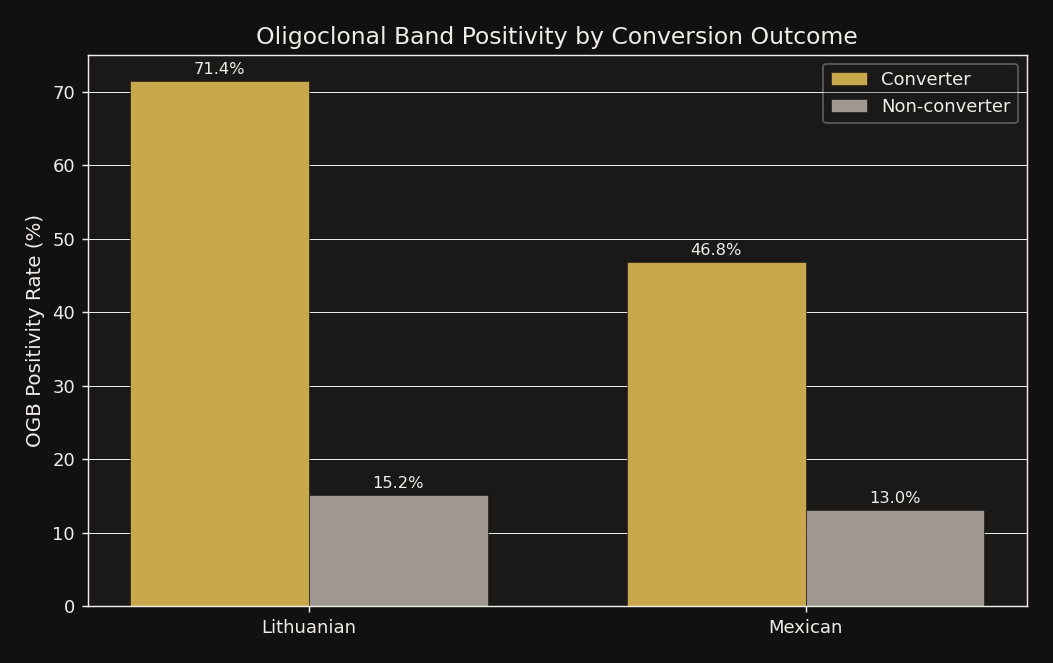

Saved: visuals/02_ogb_positivity.png


In [4]:
lt_ogb_c  = lt.loc[lt['MS'] == 1.0, 'ogb_bin'].mean() * 100
lt_ogb_nc = lt.loc[lt['MS'] == 0.0, 'ogb_bin'].mean() * 100
mx_ogb_c  = mx.loc[mx['group_bin'] == 1, 'ogb_bin'].mean() * 100
mx_ogb_nc = mx.loc[mx['group_bin'] == 0, 'ogb_bin'].mean() * 100

conv_vals  = [lt_ogb_c,  mx_ogb_c]
nconv_vals = [lt_ogb_nc, mx_ogb_nc]
x = np.arange(2)
w = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, conv_vals,  w, color=GOLD,  label='Converter',     edgecolor=BG, linewidth=0.3)
b2 = ax.bar(x + w/2, nconv_vals, w, color=MUTED, label='Non-converter', edgecolor=BG, linewidth=0.3)
for bar, v in zip(b1, conv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
for bar, v in zip(b2, nconv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(COHORTS)
ax.set_ylabel('OGB Positivity Rate (%)')
ax.set_title('Oligoclonal Band Positivity by Conversion Outcome')
ax.legend(framealpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('../visuals/02_ogb_positivity.png')
plt.show()
print('Saved: visuals/02_ogb_positivity.png')

## Chart 3: Average Age at Presentation by Conversion Outcome

Age at CIS onset can influence prognosis: younger patients with a first demyelinating event sometimes face higher long-term MS risk. Comparing mean age between converters and non-converters in each cohort also helps identify potential demographic confounders — if the cohorts differ substantially in age profile, biomarker comparisons must be interpreted with that in mind.

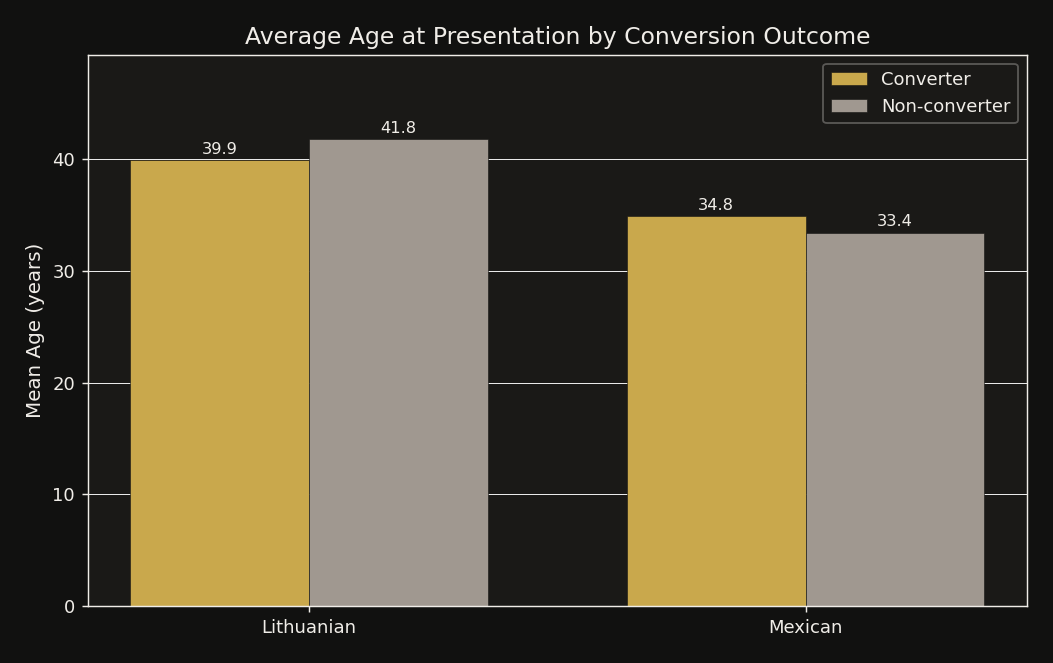

Saved: visuals/03_age_by_outcome.png


In [5]:
lt_age_c  = lt.loc[lt['MS'] == 1.0, 'Age'].mean()
lt_age_nc = lt.loc[lt['MS'] == 0.0, 'Age'].mean()
mx_age_c  = mx.loc[mx['group_bin'] == 1, 'Age (y)'].mean()
mx_age_nc = mx.loc[mx['group_bin'] == 0, 'Age (y)'].mean()

conv_ages  = [lt_age_c,  mx_age_c]
nconv_ages = [lt_age_nc, mx_age_nc]
x = np.arange(2)
w = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, conv_ages,  w, color=GOLD,  label='Converter',     edgecolor=BG, linewidth=0.3)
b2 = ax.bar(x + w/2, nconv_ages, w, color=MUTED, label='Non-converter', edgecolor=BG, linewidth=0.3)
for bar, v in zip(b1, conv_ages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}', ha='center', va='bottom', fontsize=9, color=TEXT)
for bar, v in zip(b2, nconv_ages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}', ha='center', va='bottom', fontsize=9, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(COHORTS)
ax.set_ylabel('Mean Age (years)')
ax.set_title('Average Age at Presentation by Conversion Outcome')
ax.legend(framealpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.set_ylim(0, max(max(conv_ages), max(nconv_ages)) * 1.18)
plt.tight_layout()
plt.savefig('../visuals/03_age_by_outcome.png')
plt.show()
print('Saved: visuals/03_age_by_outcome.png')

## Chart 4: Lithuanian Correlation Heatmap

A Pearson correlation matrix of all numeric variables in the Lithuanian dataset (patient ID `Nr` excluded). The diverging colour scale runs from navy (strong negative correlation) through the dark chart background (near-zero) to burgundy (strong positive). Clustering of clinical severity scores and MRI markers with the `MS` outcome column is of particular interest. Note that several columns with meaningful clinical data (Periventricular, VEP+, OGB+) were stored as strings in the source and are therefore absent from this numeric-only view.

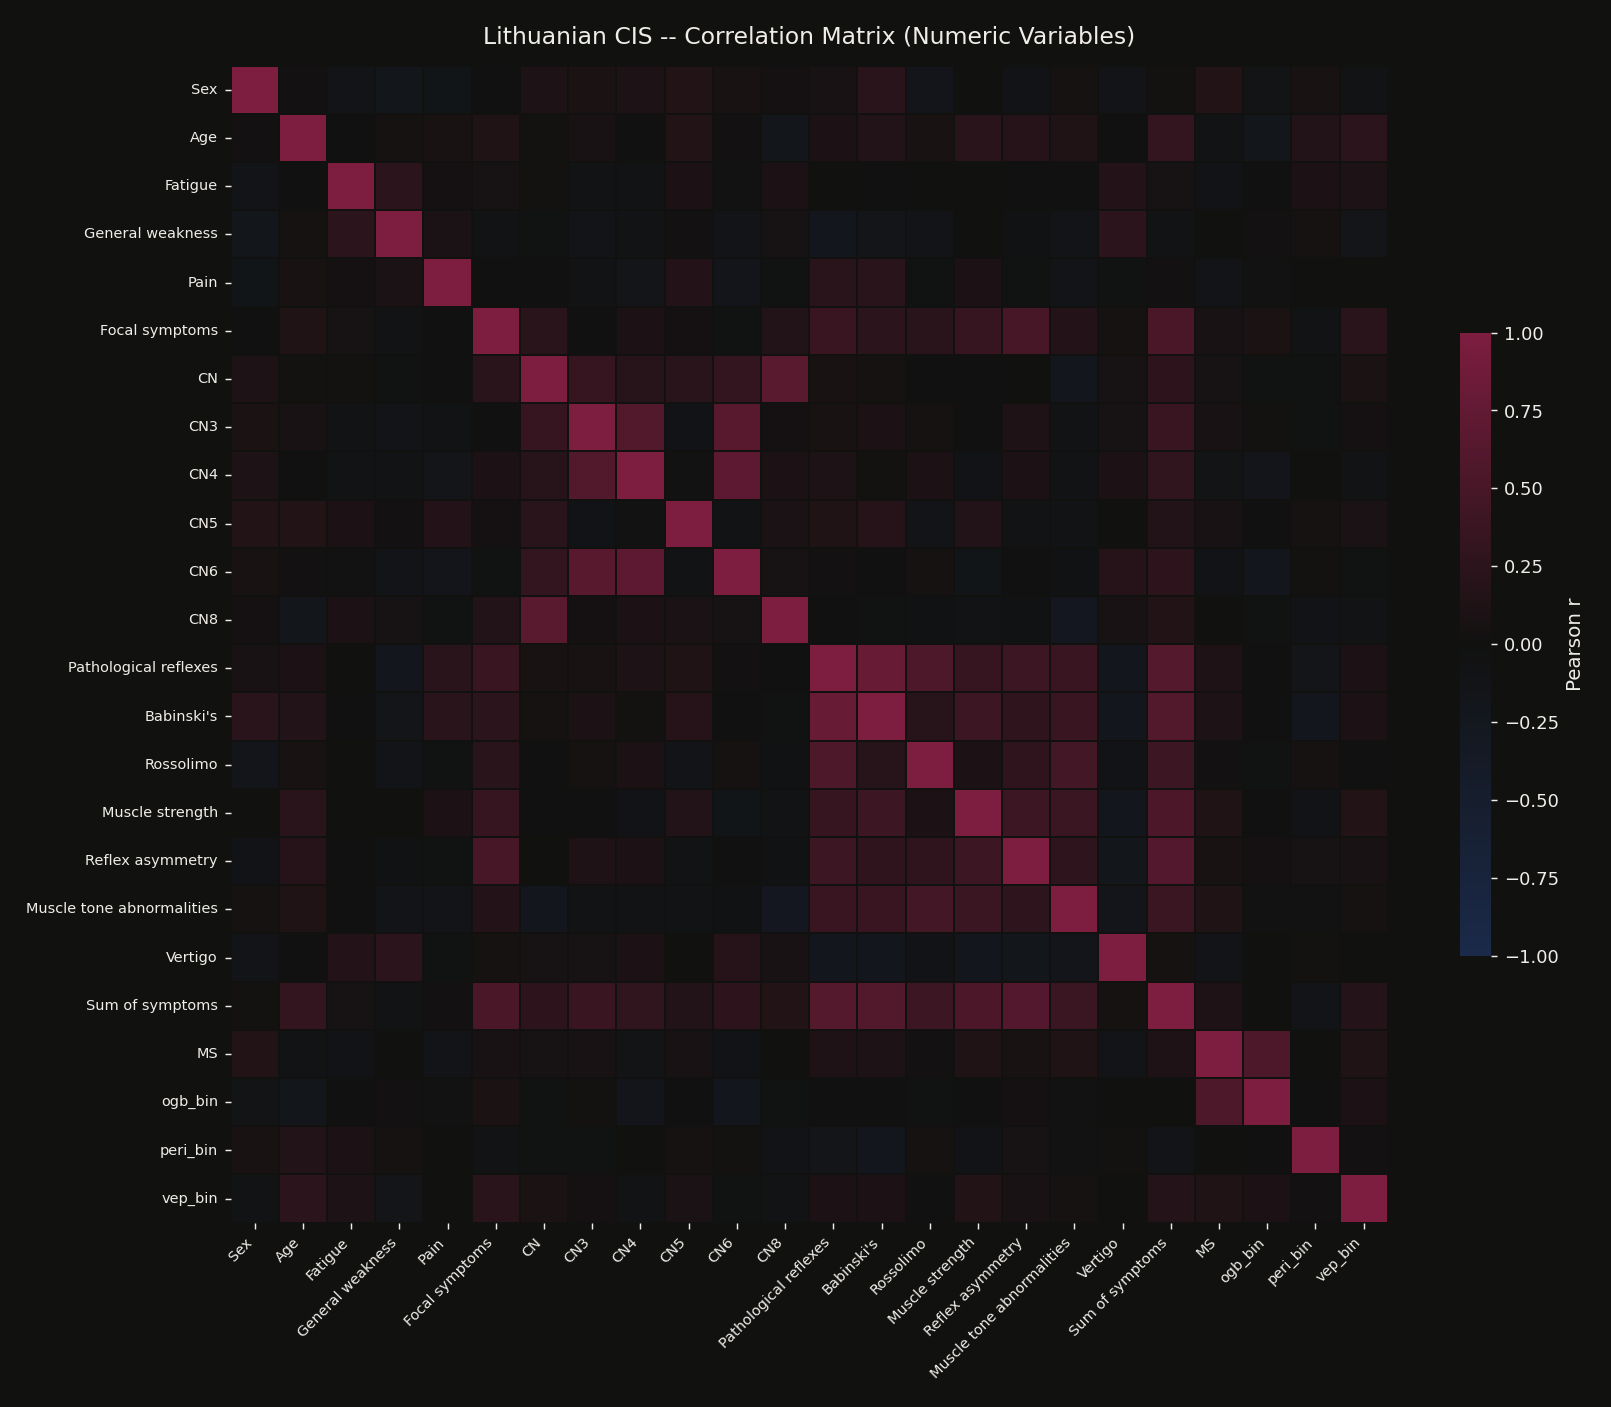

Saved: visuals/04_lithuanian_correlation.png


In [6]:
lt_num  = lt.select_dtypes(include='number').drop(columns=['Nr'], errors='ignore')
lt_corr = lt_num.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    lt_corr, ax=ax, cmap=CMAP_DIV, vmin=-1, vmax=1, center=0,
    annot=False, square=True, linewidths=0.25, linecolor=BG,
    cbar_kws={'shrink': 0.5, 'label': 'Pearson r'},
)
ax.set_title('Lithuanian CIS -- Correlation Matrix (Numeric Variables)', pad=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.savefig('../visuals/04_lithuanian_correlation.png')
plt.show()
print('Saved: visuals/04_lithuanian_correlation.png')

## Chart 5: Mexican Correlation Heatmap

The Mexican dataset stores most clinical variables as strings (e.g. `'1'`, `'0= Negative'`). To produce a meaningful correlation matrix, each string column is coerced to numeric by extracting its leading digit (`str[0]`), making `'0= Negative'` → 0 and `'1=  Positive'` → 1. Multi-category variables (`Breastfeeding`, `Varicella`, `initial symptom`) retain their original ordinal codes. The `Patient` ID and any derived helper columns are excluded. The same diverging brand colormap is applied for direct visual comparability with the Lithuanian heatmap.

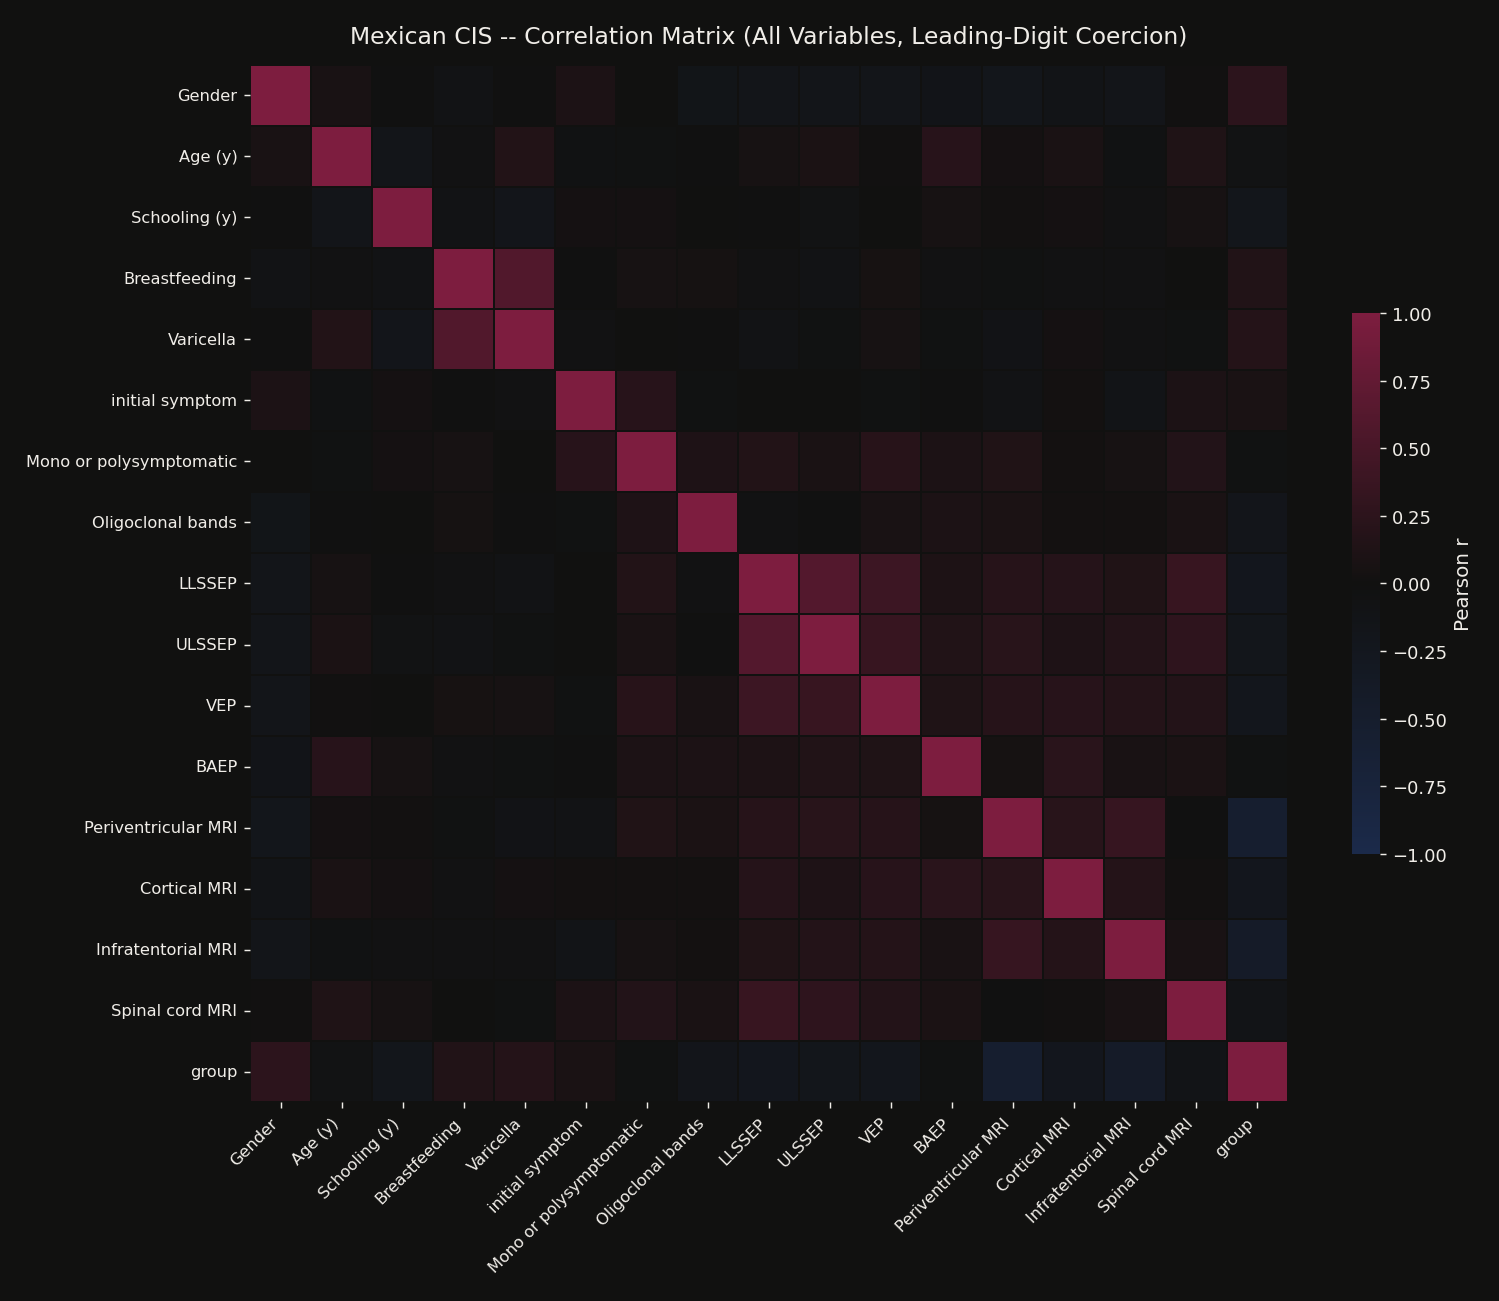

Saved: visuals/05_mexican_correlation.png


In [7]:
_derived = ['group_bin', 'ogb_bin', 'peri_bin', 'vep_bin']
mx_num = mx.drop(columns=['Patient'] + _derived, errors='ignore').copy()
for col in mx_num.columns:
    if mx_num[col].dtype.kind not in 'ifu':
        mx_num[col] = pd.to_numeric(
            mx_num[col].astype(str).str.strip().str[0], errors='coerce'
        )
mx_corr = mx_num.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    mx_corr, ax=ax, cmap=CMAP_DIV, vmin=-1, vmax=1, center=0,
    annot=False, square=True, linewidths=0.25, linecolor=BG,
    cbar_kws={'shrink': 0.5, 'label': 'Pearson r'},
)
ax.set_title('Mexican CIS -- Correlation Matrix (All Variables, Leading-Digit Coercion)', pad=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.savefig('../visuals/05_mexican_correlation.png')
plt.show()
print('Saved: visuals/05_mexican_correlation.png')

## Chart 6: Periventricular MRI Lesion Presence by Conversion Outcome

Periventricular lesions are one of the four McDonald dissemination-in-space criteria; their presence at CIS substantially raises the probability of MS diagnosis. This chart shows what proportion of converters versus non-converters had at least one periventricular lesion documented at baseline, separated by cohort. A large gap between converters and non-converters within a cohort indicates strong discriminatory power for this MRI feature in that population.

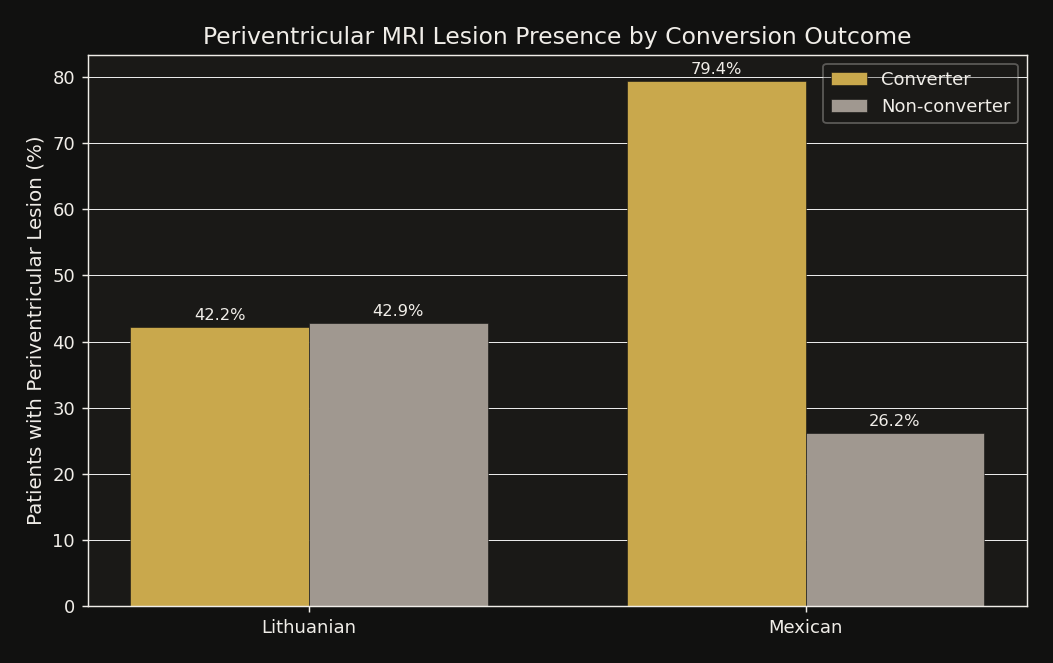

Saved: visuals/06_periventricular_mri.png


In [8]:
lt_peri_c  = lt.loc[lt['MS'] == 1.0, 'peri_bin'].mean() * 100
lt_peri_nc = lt.loc[lt['MS'] == 0.0, 'peri_bin'].mean() * 100
mx_peri_c  = mx.loc[mx['group_bin'] == 1, 'peri_bin'].mean() * 100
mx_peri_nc = mx.loc[mx['group_bin'] == 0, 'peri_bin'].mean() * 100

conv_peri  = [lt_peri_c,  mx_peri_c]
nconv_peri = [lt_peri_nc, mx_peri_nc]
x = np.arange(2)
w = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, conv_peri,  w, color=GOLD,  label='Converter',     edgecolor=BG, linewidth=0.3)
b2 = ax.bar(x + w/2, nconv_peri, w, color=MUTED, label='Non-converter', edgecolor=BG, linewidth=0.3)
for bar, v in zip(b1, conv_peri):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
for bar, v in zip(b2, nconv_peri):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(COHORTS)
ax.set_ylabel('Patients with Periventricular Lesion (%)')
ax.set_title('Periventricular MRI Lesion Presence by Conversion Outcome')
ax.legend(framealpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('../visuals/06_periventricular_mri.png')
plt.show()
print('Saved: visuals/06_periventricular_mri.png')

## Chart 7: VEP Positivity by Conversion Outcome

Visual evoked potentials (VEP) detect subclinical optic nerve demyelination — a prolonged P100 latency indicates prior or ongoing white matter damage even in the absence of a reported visual episode. As a measure of dissemination in time and space, abnormal VEP at CIS onset can support an early MS diagnosis. This chart tests whether VEP positivity differs meaningfully between eventual converters and non-converters in each cohort.

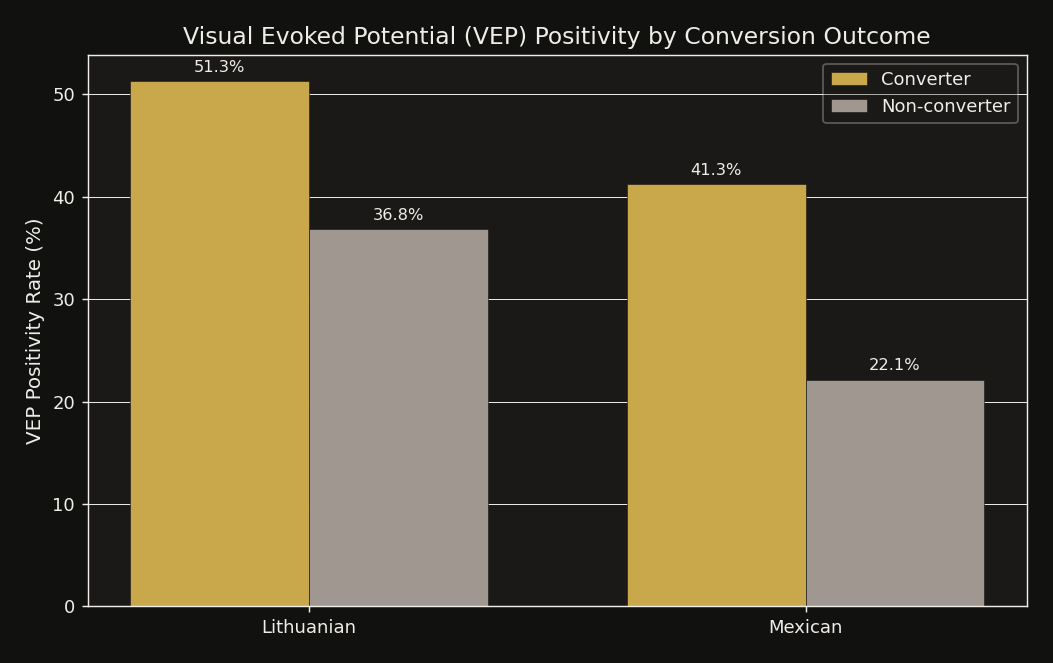

Saved: visuals/07_vep_positivity.png


In [9]:
lt_vep_c  = lt.loc[lt['MS'] == 1.0, 'vep_bin'].mean() * 100
lt_vep_nc = lt.loc[lt['MS'] == 0.0, 'vep_bin'].mean() * 100
mx_vep_c  = mx.loc[mx['group_bin'] == 1, 'vep_bin'].mean() * 100
mx_vep_nc = mx.loc[mx['group_bin'] == 0, 'vep_bin'].mean() * 100

conv_vep  = [lt_vep_c,  mx_vep_c]
nconv_vep = [lt_vep_nc, mx_vep_nc]
x = np.arange(2)
w = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, conv_vep,  w, color=GOLD,  label='Converter',     edgecolor=BG, linewidth=0.3)
b2 = ax.bar(x + w/2, nconv_vep, w, color=MUTED, label='Non-converter', edgecolor=BG, linewidth=0.3)
for bar, v in zip(b1, conv_vep):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
for bar, v in zip(b2, nconv_vep):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(COHORTS)
ax.set_ylabel('VEP Positivity Rate (%)')
ax.set_title('Visual Evoked Potential (VEP) Positivity by Conversion Outcome')
ax.legend(framealpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('../visuals/07_vep_positivity.png')
plt.show()
print('Saved: visuals/07_vep_positivity.png')